In [2]:
# библиотеки
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import scipy.stats as sts
from itertools import combinations
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
# load data
%store -r data
print(data["status"].value_counts())

status
finished        994
on_hiatus         5
discontinued      1
Name: count, dtype: int64


In [4]:
print("Нулевая гипотеза (H0): Медианы score одинаковы для всех групп.")
print("Альтернативная гипотеза (H1): Хотя бы одна группа имеет отличную медиану.")

Нулевая гипотеза (H0): Медианы score одинаковы для всех групп.
Альтернативная гипотеза (H1): Хотя бы одна группа имеет отличную медиану.


In [5]:
sample_df = data.groupby('type', group_keys=False).apply(lambda x: x.sample(min(len(x), 10), random_state=9))
groups = sample_df.groupby("type")["score"].apply(list)

# Шаг 3: Проверка количества групп (должно быть >2)
print("Количество наблюдений по типам:")
print(sample_df["type"].value_counts())

# Шаг 4: Применение теста Крускала-Уоллиса
stat, p_value = sts.kruskal(*groups)

# Вывод результатов
print("\nРезультаты теста Крускала-Уоллиса:")
print(f"Статистика = {stat:.3f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Есть статистически значимые различия между группами (отвергаем H₀).")
else:
    print("Нет значимых различий между группами (не отвергаем H₀).")

Количество наблюдений по типам:
type
doujinshi      10
light_novel    10
manga          10
manhua         10
manhwa         10
novel           7
Name: count, dtype: int64

Результаты теста Крускала-Уоллиса:
Статистика = 22.821, p-value = 0.0004
Есть статистически значимые различия между группами (отвергаем H₀).


/tmp/ipykernel_19033/435033145.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = data.groupby('type', group_keys=False).apply(lambda x: x.sample(min(len(x), 10), random_state=9))


<Axes: xlabel='type', ylabel='score'>

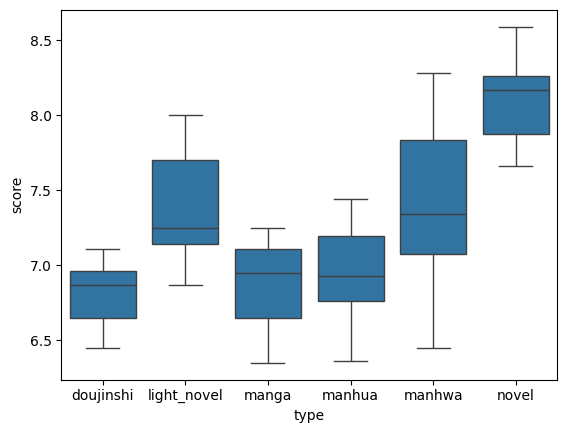

In [6]:
sns.boxplot(x='type', y='score', data=sample_df, showfliers=False)

In [ ]:
filtered_data = data[data["status"].isin(["finished", "on_hiatus"])]
df = filtered_data.groupby('status', group_keys=False).apply(lambda x: x.sample(min(len(x), 5), random_state=10))

print(df['status'].value_counts())
group1 = df[df["status"] == "finished"]["chapters"].dropna()
group2 = df[df["status"] == "on_hiatus"]["chapters"].dropna()

_,p1  = sts.shapiro(group1)
_,p2  = sts.shapiro(group2)

print("Нормальность Finished:", p1)
print("Нормальность Publishing:", p2)

stat, p_value = sts.mannwhitneyu(group1, group2, alternative='two-sided')

print("\nРезультат теста:")
print("Статистика U:", stat)
print("p-value:", p_value)

# Интерпретация
alpha = 0.05
if p_value < alpha:
    print("Есть статистически значимые различия в количестве глав между группами.")
else:
    print("Различий в количестве глав не обнаружено.")

status
finished     5
on_hiatus    5
Name: count, dtype: int64
Нормальность Finished: 0.17640840136087177
Нормальность Publishing: 0.42780228566842937

Результат теста:
Статистика U: 1.0
p-value: 0.021176657854316622
Есть статистически значимые различия в количестве глав между группами.


/tmp/ipykernel_19033/1608759429.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = filtered_data.groupby('status', group_keys=False).apply(lambda x: x.sample(min(len(x), 5), random_state=10))


<Axes: xlabel='status', ylabel='chapters'>

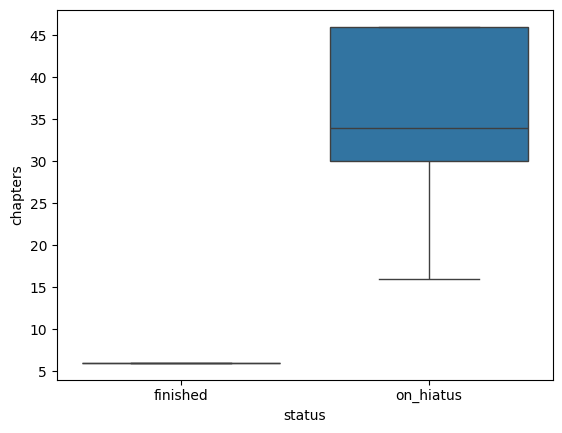

In [8]:
sns.boxplot(x='status', y='chapters', data=df, showfliers=False)